In [7]:
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path(".").resolve()

METHODS = {
    "MFI":            str(ROOT / "EXP003" / "results" / "summary_{bank_type}_{bank_id}_MFI.csv"),
    "DQN (normal)":   str(ROOT / "EXP003" / "results" / "summary_{bank_type}_{bank_id}_DQN_normal_gamma_0.1.csv"),
    "DQN (uniform)":  str(ROOT / "EXP003" / "results" / "summary_{bank_type}_{bank_id}_DQN_uniform_gamma_0.1.csv"),
    "DRQN (normal)":  str(ROOT / "EXP002" / "results" / "summary_{bank_type}_{bank_id}_DRQN_burnin_5_normal_gamma_0.1.csv"),
}

# 色 = アルゴリズム系統、線種 = normal(solid) / uniform(dashed)
COLORS = {
    "MFI":           "dimgray",
    "DQN (normal)":  "darkorange",
    "DQN (uniform)": "darkorange",
    "DRQN (normal)": "steelblue",
}
LINESTYLES = {
    "MFI":           "-",
    "DQN (normal)":  "-",
    "DQN (uniform)": "--",
    "DRQN (normal)": "-",
}

BANK_TYPES = ["uncor", "cor"]
BANK_IDS   = [1, 2, 3]
METRICS    = ["Bias", "RMSE", "MAE"]

In [8]:
def load_avg(pattern: str, bank_type: str, bank_ids: list) -> pd.DataFrame:
    """bank_id 1~3 の CSV を読み込み、ステップごとの平均を返す。"""
    dfs = []
    for bid in bank_ids:
        path = Path(pattern.format(bank_type=bank_type, bank_id=bid))
        df = pd.read_csv(path)[["step", "Bias", "RMSE", "MAE"]]
        df["step"] = df["step"].astype(int)
        dfs.append(df.set_index("step"))
    return pd.concat(dfs).groupby(level=0).mean()


# data[method_label][bank_type] = DataFrame (index=step, columns=Bias/RMSE/MAE)
data = {}
for label, pattern in METHODS.items():
    data[label] = {}
    for bt in BANK_TYPES:
        data[label][bt] = load_avg(pattern, bt, BANK_IDS)
        print(f"{label:25s} {bt}: {len(data[label][bt])} steps")

MFI                       uncor: 40 steps
MFI                       cor: 40 steps
DQN (normal)              uncor: 40 steps
DQN (normal)              cor: 40 steps
DQN (uniform)             uncor: 40 steps
DQN (uniform)             cor: 40 steps
DRQN (normal)             uncor: 40 steps
DRQN (normal)             cor: 40 steps


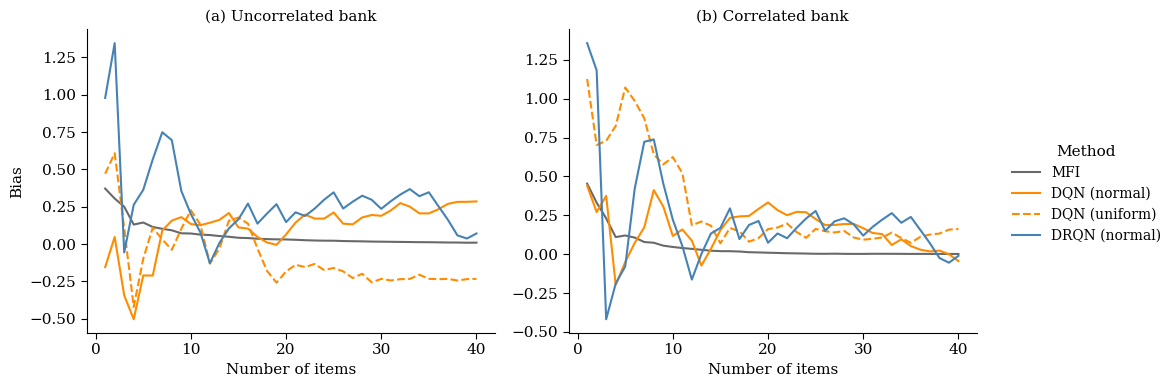

Saved: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/plot_results_bias.png


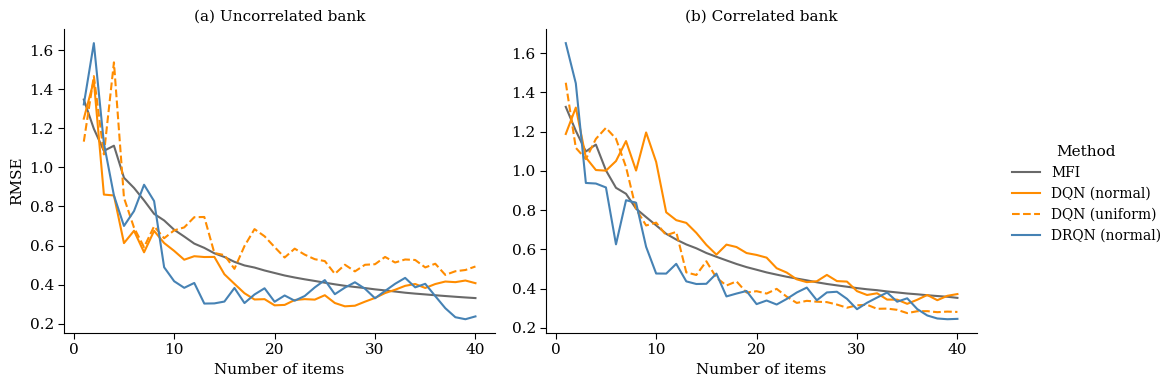

Saved: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/plot_results_rmse.png


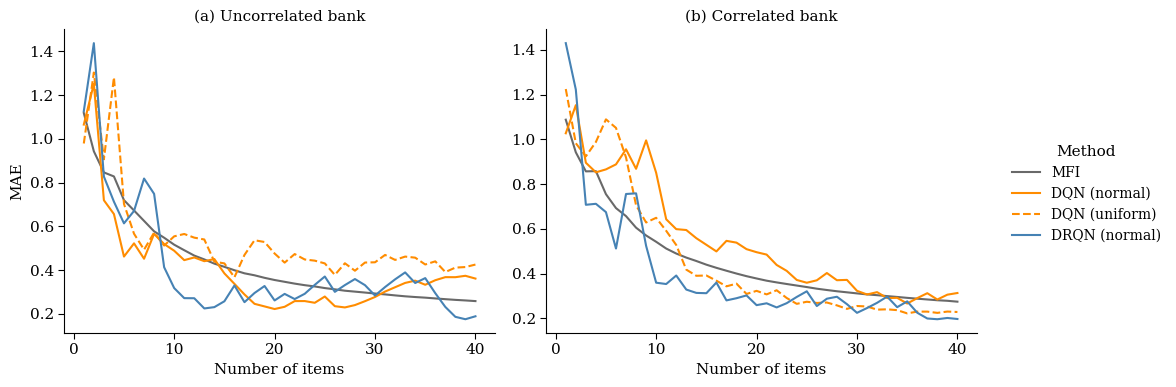

Saved: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/plot_results_mae.png


In [9]:
mpl.rcParams.update({
    "font.family":        "serif",
    "font.size":          11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.linewidth":     0.8,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
})

SUBTITLE = {
    "uncor": "(a) Uncorrelated bank",
    "cor":   "(b) Correlated bank",
}

for metric in METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for col, bt in enumerate(BANK_TYPES):
        ax = axes[col]
        for label in METHODS:
            df = data[label][bt]
            ax.plot(
                df.index,
                df[metric],
                color=COLORS[label],
                linestyle=LINESTYLES[label],
                linewidth=1.5,
                label=label,
            )
        ax.set_title(SUBTITLE[bt], fontsize=11)
        ax.set_xlabel("Number of items", fontsize=11)
        ax.set_ylabel(metric if col == 0 else "", fontsize=11)
        ax.set_xticks([0, 10, 20, 30, 40])

    # 右外に凡例（論文スタイル）
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Method",
        loc="center right",
        bbox_to_anchor=(1.18, 0.5),
        frameon=False,
        fontsize=10,
        title_fontsize=11,
    )

    plt.tight_layout()
    out = ROOT / f"plot_results_{metric.lower()}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")